In [6]:
import logging
import pathlib

import h5py
import paint.util.paint_mappings as paint_mappings
import torch
from matplotlib import pyplot as plt

from artist.core.heliostat_ray_tracer import HeliostatRayTracer
from artist.core.kinematic_reconstructor import KinematicReconstructor
from artist.core.loss_functions import FocalSpotLoss
from artist.data_parser.calibration_data_parser import CalibrationDataParser
from artist.data_parser.paint_calibration_parser import PaintCalibrationDataParser
from artist.scenario.scenario import Scenario
from artist.util import config_dictionary, set_logger_config
from artist.util.environment_setup import get_device, setup_distributed_environment

torch.manual_seed(7)
torch.cuda.manual_seed(7)

#############################################################################################################
# Define helper functions for the plots.
# Skip to line 143 for the tutorial code.
#############################################################################################################


def create_fluxes(
    data_parser: CalibrationDataParser,
    scenario: Scenario,
    heliostat_data_mapping: list,
    device: torch.device,
) -> tuple[list[torch.Tensor], list[torch.Tensor]]:
    """
    Create data to plot the heliostat fluxes.

    Parameters
    ----------
    data_parser : CalibrationDataParser
        The data parser used to load calibration data from files.
    scenario : Scenario
        The scenario containing the heliostat field and target areas.
    heliostat_data_mapping : list
        Mapping of heliostats to their calibration data paths.
    device : torch.device
        The device to use for computations.

    Returns
    -------
    list[torch.Tensor]
        Bitmaps per heliostat.
    list[torch.Tensor]
        Measured flux bitmap.
    """

# 

    bitmaps = []
    measured_bitmaps = []
    scenario.set_number_of_rays(number_of_rays=500)
    for heliostat_group in scenario.heliostat_field.heliostat_groups:
        (
            measured_flux,
            _,
            incident_ray_directions,
            _,
            active_heliostats_mask,
            target_area_mask,
        ) = data_parser.parse_data_for_reconstruction(
            heliostat_data_mapping=heliostat_data_mapping,
            heliostat_group=heliostat_group,
            scenario=scenario,
            bitmap_resolution=torch.tensor([256, 256]),
            device=device,
        )

        measured_bitmaps.append(measured_flux)
        
        # DIAGNOSTIC: Check measured flux
        print(f"Measured flux shape: {measured_flux.shape}")
        print(f"Measured flux sum: {measured_flux.sum()}")
        print(f"Measured flux max: {measured_flux.max()}")
        print(f"Active heliostats: {active_heliostats_mask.sum()}")
        print(f"Target area mask: {target_area_mask}")

        # Activate heliostats.
        heliostat_group.activate_heliostats(
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Align heliostats.
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.target_areas.centers[target_area_mask],
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Create a ray tracer.
        ray_tracer = HeliostatRayTracer(
            scenario=scenario,
            heliostat_group=heliostat_group,
            batch_size=heliostat_group.number_of_active_heliostats,
            bitmap_resolution=torch.tensor([256, 256], device=device),
        )

        # Perform heliostat-based ray tracing.
        bitmaps_per_heliostat = ray_tracer.trace_rays(
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            target_area_mask=target_area_mask,
            device=device,
        )
        
        # DIAGNOSTIC: Check simulated flux
        print(f"Simulated flux shape: {bitmaps_per_heliostat.shape}")
        print(f"Simulated flux sum: {bitmaps_per_heliostat.sum()}")
        print(f"Simulated flux max: {bitmaps_per_heliostat.max()}")
        
        bitmaps.append(bitmaps_per_heliostat)

    scenario.set_number_of_rays(number_of_rays=4)

    return bitmaps, measured_bitmaps


def create_plots(
    fluxes_before: torch.Tensor,
    fluxes_after: torch.Tensor,
    fluxes_measured: torch.Tensor,
) -> None:
    """
    Create the plots with the reconstruction results.

    Parameters
    ----------
    flux_before : torch.Tensor
        Flux before kinematic reconstruction.
    flux_after : torch.Tensor
        Flux after kinematic reconstruction.
    flux_measured : torch.Tensor
        Measured flux reference.
    """
    for group_index, (flux_before, flux_after, flux_measured) in enumerate(
        zip(fluxes_before, fluxes_after, fluxes_measured)
    ):
        for i in range(len(flux_before)):
            _, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

            axes[0].imshow(flux_before[i].cpu().detach(), cmap="gray")
            axes[0].set_title("Before reconstruction", fontsize=16)
            axes[0].axis("off")

            axes[1].imshow(flux_after[i].cpu().detach(), cmap="gray")
            axes[1].set_title("After reconstruction", fontsize=16)
            axes[1].axis("off")

            axes[2].imshow(flux_measured[i].cpu().detach(), cmap="gray")
            axes[2].set_title("Measured", fontsize=16)
            axes[2].axis("off")

            plt.subplots_adjust(wspace=0.05)
            plt.savefig(f"heliostat_{i}_in_group_{group_index}_calibration.png")
            plt.show()


#############################################################################################################
# Tutorial
#############################################################################################################
def optimize_motor_scenario(scenario_path: str) -> None:
    """
    Optimize a scenario with motor calibration data.

    Parameters
    ----------
    scenario_path : str
        Path to the scenario.h5 file.
    """
    # Set up logger.
    set_logger_config()
    log = logging.getLogger(__name__)

    # Set the device.
    device = get_device()

    # Specify the path to your scenario.h5 file.
    scenario_path = pathlib.Path(scenario_path)

    # Also specify the heliostats to be calibrated and the paths to your calibration-properties.json files.
    # Please use the following style: list[tuple[str, list[pathlib.Path], list[pathlib.Path]]]
    heliostat_data_mapping = [
        (
            "AA31",
            [
                pathlib.Path(
                    "paint_data/AA31/Calibration/118385/properties.json"
                ),
                # ....
            ],
            [
                pathlib.Path("paint_data/AA31/Calibration/118385/flux.png"),
                # ....
            ],
        ),
        # (
        #     "heliostat_name_2",
        #     [
        #         pathlib.Path(
        #             "please/insert/the/path/to/the/paint/data/here/calibration-properties.json"
        #         ),
        #         # ....\
        #     ],
        #     [
        #         pathlib.Path("please/insert/the/path/to/the/paint/data/here/flux.png"),
        #         # ....
        #     ],
        # ),
        # ...
    ]

    # Or if you have a directory with downloaded data use this code to create a mapping.
    # heliostat_data_mapping = paint_scenario_parser.build_heliostat_data_mapping(
    #     base_path="base/path/data",
    #     heliostat_names=["heliostat_1", "..."],
    #     number_of_measurements=5,
    #     image_variant="flux",
    #     randomize=True,
    # )

    data_parser = PaintCalibrationDataParser(
        sample_limit=50, centroid_extraction_method=paint_mappings.UTIS_KEY
    )
    data_parser_plots = PaintCalibrationDataParser(
        sample_limit=1, centroid_extraction_method=paint_mappings.UTIS_KEY
    )

    # Create dict for the data parser and the heliostat_data_mapping.
    data: dict[
        str,
        CalibrationDataParser | list[tuple[str, list[pathlib.Path], list[pathlib.Path]]],
    ] = {
        config_dictionary.data_parser: data_parser,
        config_dictionary.heliostat_data_mapping: heliostat_data_mapping,
    }

    number_of_heliostat_groups = Scenario.get_number_of_heliostat_groups_from_hdf5(
        scenario_path=scenario_path
    )

    with setup_distributed_environment(
        number_of_heliostat_groups=number_of_heliostat_groups,
        device=device,
    ) as ddp_setup:
        device = ddp_setup[config_dictionary.device]

        # Load the scenario.
        with h5py.File(scenario_path, "r") as scenario_file:
            scenario = Scenario.load_scenario_from_hdf5(
                scenario_file=scenario_file, device=device
            )

        # Configure the learning rate scheduler. The example scheduler parameter dict includes
        # example parameters for all three possible schedulers.
        scheduler = (
            config_dictionary.reduce_on_plateau
        )  # exponential, cyclic or reduce_on_plateau
        scheduler_parameters = {
            config_dictionary.gamma: 0.9,
            config_dictionary.min: 1e-6,
            config_dictionary.max: 1e-3,
            config_dictionary.step_size_up: 500,
            config_dictionary.reduce_factor: 0.0001,
            config_dictionary.patience: 50,
            config_dictionary.threshold: 1e-3,
            config_dictionary.cooldown: 10,
        }

        # Set optimization parameters.
        optimization_configuration = {
            config_dictionary.initial_learning_rate: 0.0005,
            config_dictionary.tolerance: 0.0005,
            config_dictionary.max_epoch: 500,
            config_dictionary.log_step: 3,
            config_dictionary.early_stopping_delta: 1e-4,
            config_dictionary.early_stopping_patience: 300,
            config_dictionary.scheduler: scheduler,
            config_dictionary.scheduler_parameters: scheduler_parameters,
        }

        print("\n=== Creating BEFORE bitmaps ===")
        # create unoptimized bitmaps
        bitmaps_before, _ = create_fluxes(
            data_parser=data_parser_plots,
            scenario=scenario,
            heliostat_data_mapping=heliostat_data_mapping,
            device=device,
        )

        # Create the kinematic reconstructor.
        # This optimizes the motor/actuator angles to match the measured flux patterns
        kinematic_reconstructor = KinematicReconstructor(
            ddp_setup=ddp_setup,
            scenario=scenario,
            data=data,
            optimization_configuration=optimization_configuration,
            reconstruction_method=config_dictionary.kinematic_reconstruction_raytracing,
        )

        loss_definition = FocalSpotLoss(scenario=scenario)

        # Reconstruct the kinematic.
        final_loss_per_heliostat = kinematic_reconstructor.reconstruct_kinematic(
            loss_definition=loss_definition, device=device
        )

    # Inspect the synchronized loss per heliostat. Heliostats that have not been optimized have an infinite loss.
    print(f"\n=== FINAL RESULTS ===")
    print(f"rank {ddp_setup['rank']}, final loss per heliostat {final_loss_per_heliostat}")

    print("\n=== Creating AFTER bitmaps ===")
    bitmaps_after, bitmaps_measured = create_fluxes(
        data_parser=data_parser_plots,
        scenario=scenario,
        heliostat_data_mapping=heliostat_data_mapping,
        device=device,
    )
    create_plots(
        fluxes_before=bitmaps_before,
        fluxes_after=bitmaps_after,
        fluxes_measured=bitmaps_measured,
    )

In [7]:
scenario_paths = [
    # "tutorials/data/scenarios/single_heliostat_scenario.h5"
    # "scenarios/one_heliostat_scenarios/AA31_one_heliostat_scenario.h5",
    "scenarios/one_heliostat_scenarios/test_scenario.h5"
]

[2026-01-13 11:30:46,376][artist.util.environment_setup][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-01-13 11:30:46,376][artist.util.environment_setup][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-01-13 11:30:46,377][artist.util.environment_setup][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
[2026-01-13 11:30:46,377][artist.util.environment_setup][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
[2026-01-13 11:30:46,380][artist.util.environment_setup][INFO] - Distributed Mode disabled. Running in single-device mode.
[2026-01-13 11:30:46,380][artist.util.environment_setup][INFO] - Distributed Mode disabled. Running in single-device mode.
[2026-01-13 11:30:46,381][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2026-01-13 11:30:46,381][art

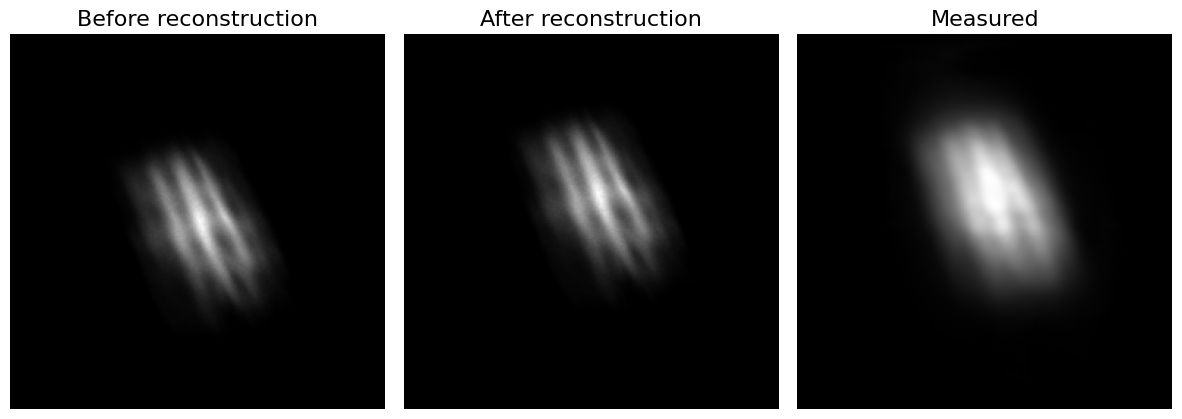

In [8]:
optimize_motor_scenario(scenario_paths[0])

#divide the loss by 1000 (for plotting purposes)

In [9]:
!pip uninstall artist-csp -y

Found existing installation: artist-csp 1.0.0
Uninstalling artist-csp-1.0.0:
  Successfully uninstalled artist-csp-1.0.0
